<a href="https://colab.research.google.com/github/vpraneethkumarreddy-sys/Python-programs/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

House Price Dataset
   Area  Bedrooms  Bathrooms    Price
0   800         1          1  1800000
1  1000         2          1  2500000
2  1200         2          2  3000000
3  1500         3          2  3800000
4  1700         3          2  4200000
5  2000         4          3  5000000
6  2200         4          3  5500000
7  2500         5          4  6500000
8  2800         5          4  7200000
9  3000         6          5  8000000

Summary Statistics
              Area   Bedrooms  Bathrooms         Price
count    10.000000  10.000000  10.000000  1.000000e+01
mean   1870.000000   3.500000   2.700000  4.750000e+06
std     758.727004   1.581139   1.337494  2.062496e+06
min     800.000000   1.000000   1.000000  1.800000e+06
25%    1275.000000   2.250000   2.000000  3.200000e+06
50%    1850.000000   3.500000   2.500000  4.600000e+06
75%    2425.000000   4.750000   3.750000  6.250000e+06
max    3000.000000   6.000000   5.000000  8.000000e+06

Missing Values
Area         0
Bedrooms     0
B

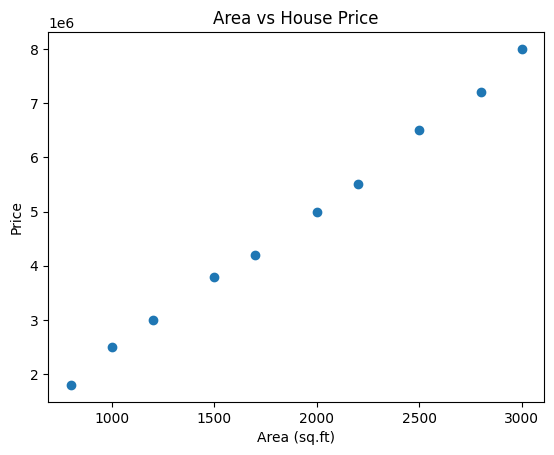


Model Evaluation
MAE: 107251.90839694557
R2 Score: 0.9970718555546515

Predicted House Prices

House 1
Input: [1400, 2, 2]
Predicted House Price: ₹3,417,812

House 2
Input: [1800, 3, 2]
Predicted House Price: ₹4,360,051

House 3
Input: [2100, 4, 3]
Predicted House Price: ₹5,337,150

House 4
Input: [2600, 5, 4]
Predicted House Price: ₹6,737,659

House 5
Input: [3200, 6, 5]
Predicted House Price: ₹8,349,873


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# House Price Dataset
data = {
    'Area': [800, 1000, 1200, 1500, 1700, 2000, 2200, 2500, 2800, 3000],
    'Bedrooms': [1, 2, 2, 3, 3, 4, 4, 5, 5, 6],
    'Bathrooms': [1, 1, 2, 2, 2, 3, 3, 4, 4, 5],
    'Price': [1800000, 2500000, 3000000, 3800000, 4200000,
              5000000, 5500000, 6500000, 7200000, 8000000]
}

# Create DataFrame
df = pd.DataFrame(data)

print("House Price Dataset")
print(df)

# Statistics
print("\nSummary Statistics")
print(df.describe())

# Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Scatter Plot
plt.scatter(df['Area'], df['Price'])
plt.title("Area vs House Price")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price")
plt.show()

# Features and Target
X = df[['Area', 'Bedrooms', 'Bathrooms']]
y = df['Price']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Test Prediction
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Evaluation")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Predict 5 New Houses
new_houses = [
    [1400, 2, 2],
    [1800, 3, 2],
    [2100, 4, 3],
    [2600, 5, 4],
    [3200, 6, 5]
]

predicted_prices = model.predict(new_houses)

print("\nPredicted House Prices")

for i in range(len(new_houses)):
    print("\nHouse", i + 1)
    print("Input:", new_houses[i])
    print("Predicted House Price: ₹{:,.0f}".format(predicted_prices[i]))